In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings("ignore")

In [7]:
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
#Check for duplicates

data.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [10]:
# checking for nulls and treating them.

data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
data.isnull().sum()/len(data)*100

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

# Feature Engineering

In [13]:
data['AgeGroup'] = pd.cut(data['Age'], bins=[20, 30, 40, 50, 60, 100],
                        labels=['20s', '30s', '40s', '50s', '60+'])


In [14]:
data['BMICategory'] = pd.cut(data['BMI'],
                           bins=[0, 18.5, 24.9, 29.9, 100],
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])


In [15]:
data['HighGlucose'] = (data['Glucose'] > 140).astype(int)


In [16]:
data['Age_BMI_Interaction'] = data['Age'] * data['BMI']


In [17]:
data['InsulinLevel'] = pd.cut(data['Insulin'],
                            bins=[0, 100, 200, 1000],
                            labels=['Low', 'Normal', 'High'])


In [18]:
data = pd.get_dummies(data, columns=['AgeGroup', 'BMICategory', 'InsulinLevel'], drop_first=True)


In [19]:
scaler = StandardScaler()
scaled_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']
data[scaled_columns] = scaler.fit_transform(data[scaled_columns])


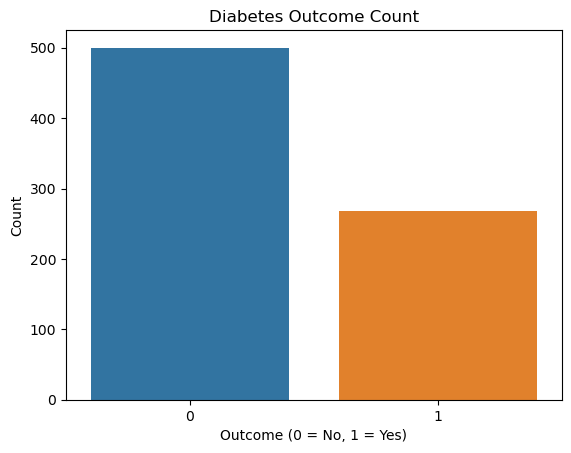

In [20]:
sns.countplot(data=data, x='Outcome')
plt.title('Diabetes Outcome Count')
plt.xlabel('Outcome (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


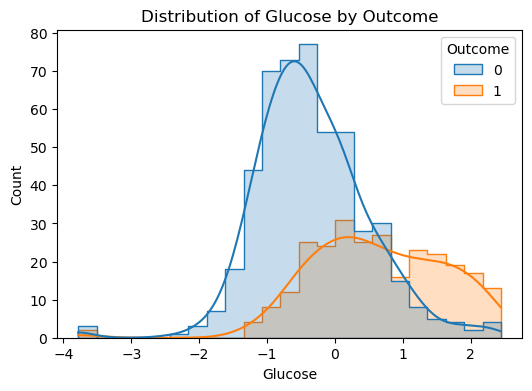

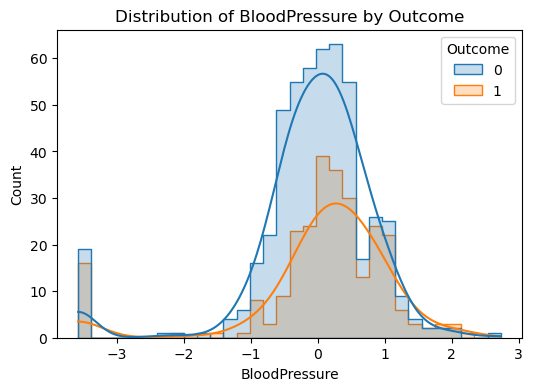

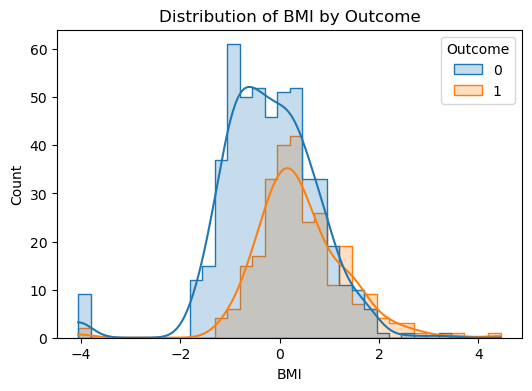

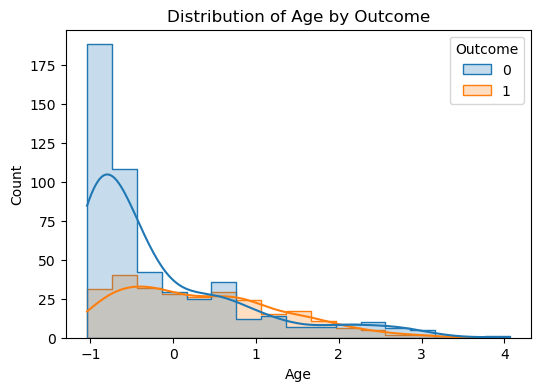

In [21]:
numeric_cols = ['Glucose', 'BloodPressure', 'BMI', 'Age']

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=data, x=col, kde=True, hue='Outcome', element='step')
    plt.title(f'Distribution of {col} by Outcome')
    plt.show()

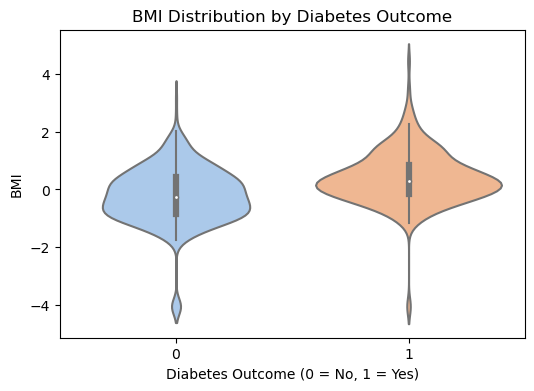

In [22]:
plt.figure(figsize=(6, 4))
sns.violinplot(data=data, x='Outcome', y='BMI', palette='pastel')
plt.title('BMI Distribution by Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No, 1 = Yes)')
plt.ylabel('BMI')
plt.show()

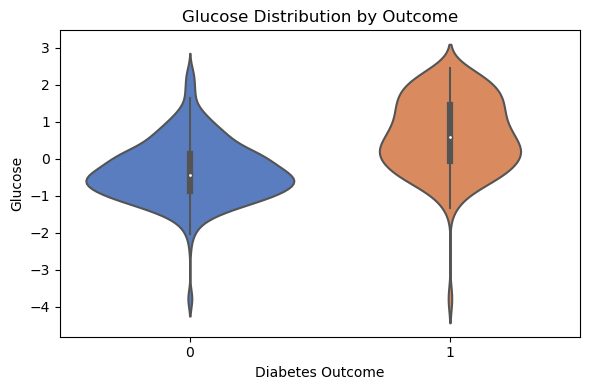

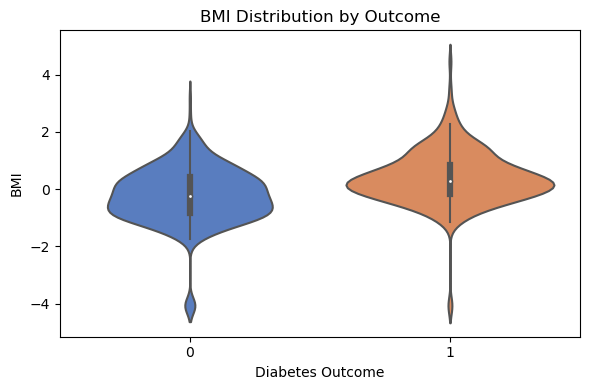

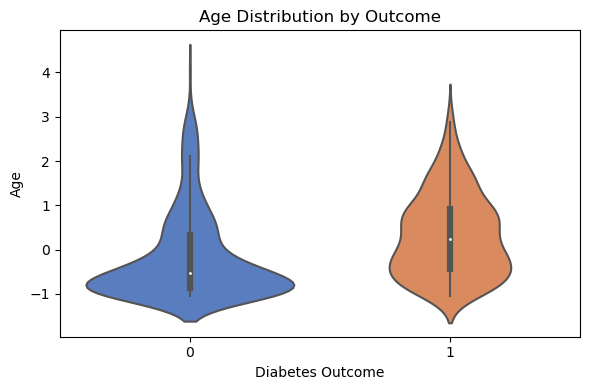

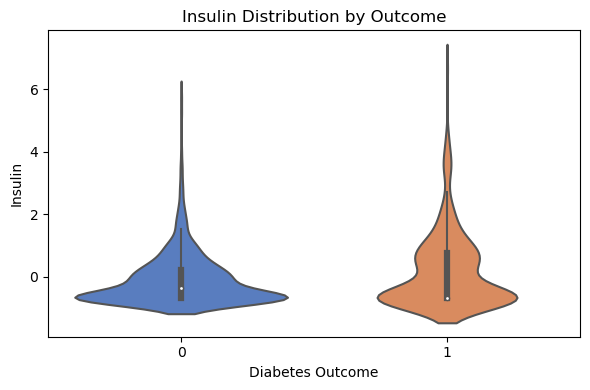

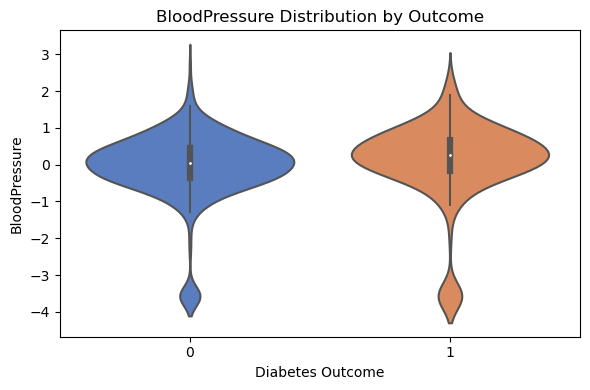

In [23]:
features = ['Glucose', 'BMI', 'Age', 'Insulin', 'BloodPressure']

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.violinplot(data=data, x='Outcome', y=feature, palette='muted')
    plt.title(f'{feature} Distribution by Outcome')
    plt.xlabel('Diabetes Outcome')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


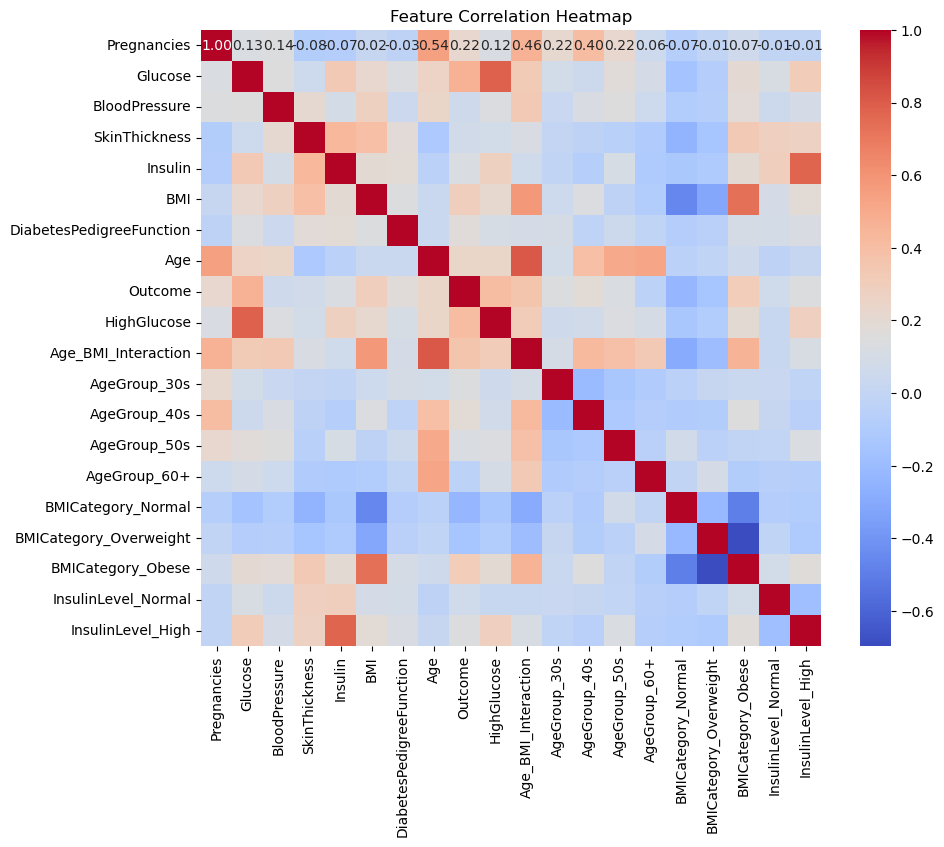

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()


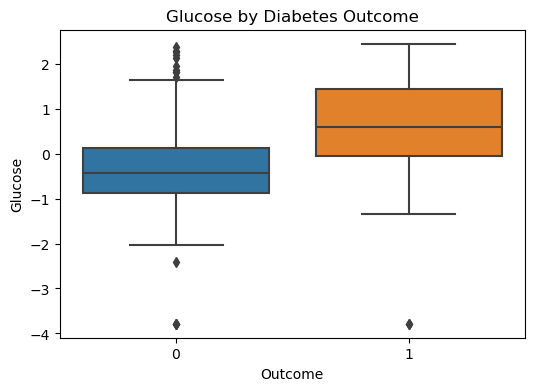

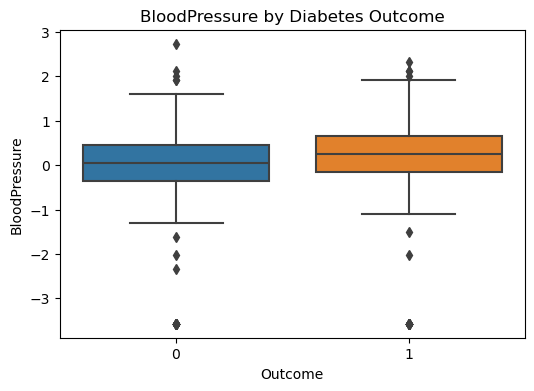

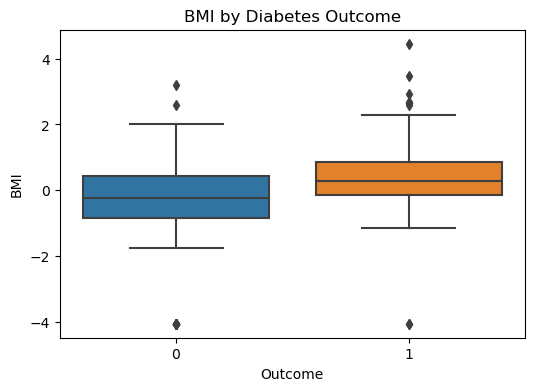

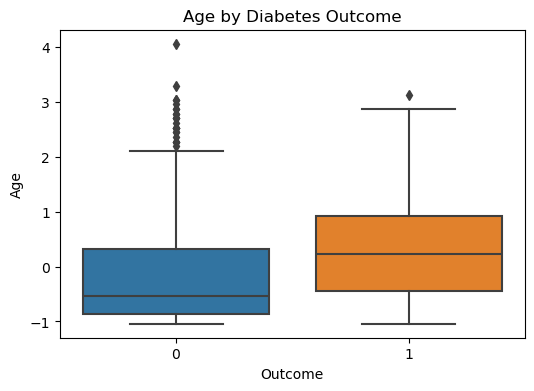

In [25]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data, x='Outcome', y=col)
    plt.title(f'{col} by Diabetes Outcome')
    plt.show()


In [26]:
# Convert Outcome to string
data['Outcome'] = data['Outcome'].astype(str)


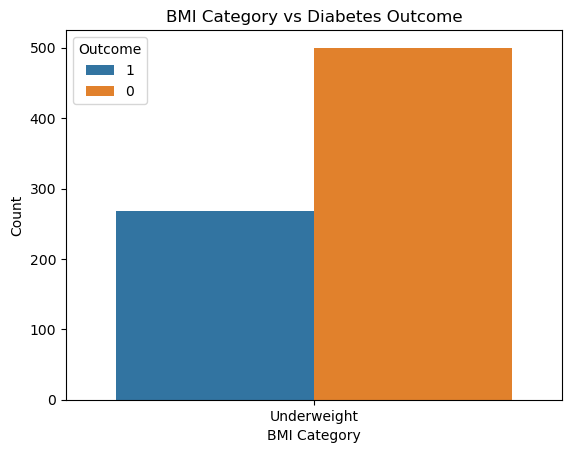

In [27]:
# Create BMI Category column
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

data['BMICategory'] = data['BMI'].apply(bmi_category)

#  plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=data, x='BMICategory', hue='Outcome')
plt.title('BMI Category vs Diabetes Outcome')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()


In [28]:
features = ['Glucose', 'BMI', 'Age', 'Insulin']

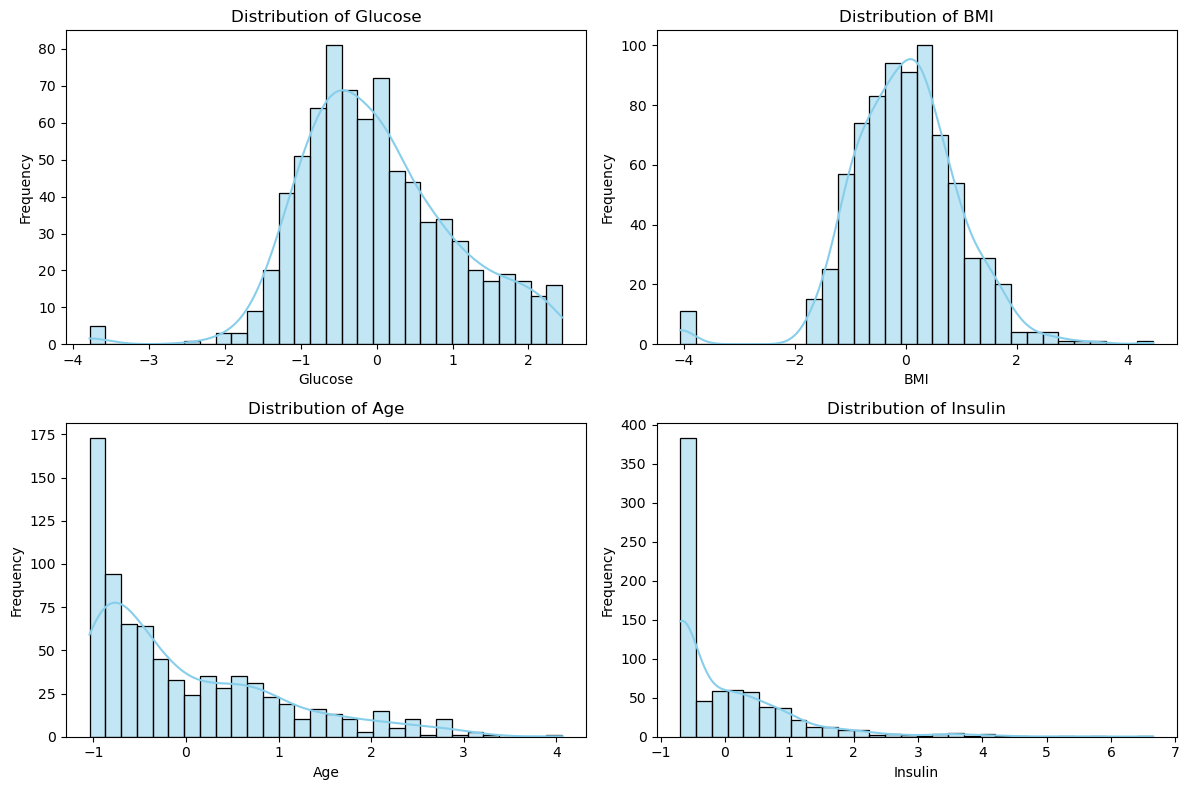

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 
axes = axes.flatten()
for i, feature in enumerate(features):
    sns.histplot(data=data, x=feature, kde=True, bins=30, color='skyblue', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [30]:
column = 'Glucose'

In [31]:
col_data = data[column].dropna()

In [32]:
# Calculate Q1, Q3, and IQR
Q1 = np.percentile(col_data, 25, interpolation='midpoint')
Q3 = np.percentile(col_data, 75, interpolation='midpoint')
IQR = Q3 - Q1


In [33]:
# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [34]:
# Identify outliers
outliers = data[(data[column] >= (Q3 + 1.5 * IQR)) | (data[column] <= (Q1 - 1.5 * IQR))]

In [35]:
display(outliers.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,HighGlucose,...,AgeGroup_30s,AgeGroup_40s,AgeGroup_50s,AgeGroup_60+,BMICategory_Normal,BMICategory_Overweight,BMICategory_Obese,InsulinLevel_Normal,InsulinLevel_High,BMICategory
75,1,-3.783654,-1.091105,-0.033651,-0.692891,-0.925569,0.140,-0.956462,0,0,...,False,False,False,False,True,False,False,False,False,Underweight
182,1,-3.783654,0.253036,-0.033651,-0.493184,-0.544811,0.299,-1.041549,0,0,...,False,False,False,False,False,True,False,False,False,Underweight
342,1,-3.783654,-0.057150,0.907270,-0.692891,0.000942,0.389,-0.956462,0,0,...,False,False,False,False,False,False,True,False,False,Underweight
349,5,-3.783654,0.563223,0.719086,-0.692891,1.143215,0.346,0.319855,1,0,...,True,False,False,False,False,False,True,False,False,Underweight
502,6,-3.783654,-0.057150,1.283638,-0.692891,0.889377,0.727,0.660206,1,0,...,False,True,False,False,False,False,True,False,False,Underweight
